## a linear variational auto-encoder on the MNIST dataset

In [3]:
import numpy as np 
import torch, pickle, torchvision, os 
import matplotlib.pyplot as plt
from torchvision import transforms 

%matplotlib inline 

In [4]:
resultsPath = os.path.join('results', '6_VAE')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath) 

In [5]:
# defining hyperparameters

n_epochs = 100
batch_size_train = 64
batch_size_test = 1000 
learning_rate = 1e-2
log_interval = 100 

random_seed = 1
torch.manual_seed(random_seed) 

# determine if CUDA is available 
if torch.cuda.is_available():
    device = 'cuda'
    print('GPU available')
else:
    device = 'cpu'
    print('only CPU available')

GPU available


In [6]:
# defining training data loader
train_data = torchvision.datasets.MNIST(
    root = 'data',
    train = True,
    download = False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean = (0.1307,),
            std = (0.3081,)
        )
    ])
)
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size_train)

In [7]:
# defining testing data and data loader
test_data = torchvision.datasets.MNIST(
    root = 'data',
    train=False,
    download=False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean = (0.1307, ),
            std = (0.3081, )
        )
    ])
)
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size_test) 

In [8]:
len(train_dataloader.dataset)

60000

In [10]:
train_feature, train_label = next(iter(train_dataloader))

In [11]:
train_feature.shape 

torch.Size([64, 1, 28, 28])

In [12]:
train_label.shape 

torch.Size([64])

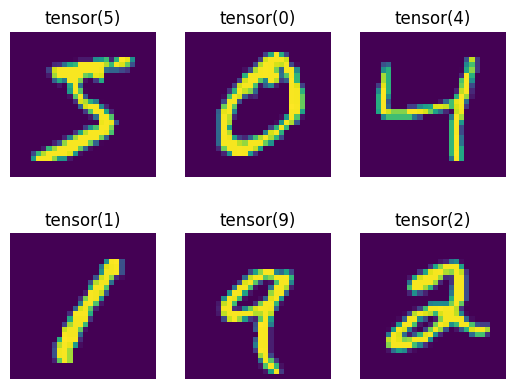

In [13]:
fig = plt.figure() 

for i in np.arange(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(train_feature[i].squeeze())
    plt.title(train_label[i])
    plt.axis('off')

In [15]:
import torch.nn.functional as F
import torch.nn as nn 

In [47]:
class VAE_linear(nn.Module):
    def __init__(self, x_dim, hidden_dim, z_dim=10):
        super().__init__()
        self.enc_layer1 = nn.Linear(in_features=x_dim, out_features=hidden_dim, bias=True) 
        self.enc_layer2_mu = nn.Linear(in_features=hidden_dim, out_features=z_dim, bias=True)
        self.enc_layer2_std = nn.Linear(in_features=hidden_dim, out_features=z_dim, bias=True)

        # decoding layers
        self.dec_layer1 = nn.Linear(in_features=z_dim, out_features=hidden_dim, bias=True)
        self.dec_layer2 = nn.Linear(in_features=hidden_dim, out_features=x_dim, bias=True) 

    def encode(self, x):
        x = F.relu(self.enc_layer1(x))
        mu = F.relu(self.enc_layer2_mu(x))
        logvar = F.relu(self.enc_layer2_std(x))

        return mu, logvar 


    def reparameterization(self, mu, logvar):
        # 2 ln(std) = logvar --> std = exp(logbar/2)
        std = torch.exp(logvar/2) 
        epsilon = torch.randn_like(std)

        return mu + epsilon * std


    def decode(self, z):
        output = F.relu(self.dec_layer1(z))
        output = F.relu(self.dec_layer2(output)) 
        
        return output 
        
    
    def forward(self, x):
        mu, logvar = self.encode(x.reshape(x.shape[0], -1))        
        z = self.reparameterization(mu, logvar)
        output = self.decode(z)
        return output 

In [48]:
latent_dim = 100
vae_linear = VAE_linear(x_dim=28*28, hidden_dim=256, z_dim=latent_dim)
vae_linear

VAE_linear(
  (enc_layer1): Linear(in_features=784, out_features=256, bias=True)
  (enc_layer2_mu): Linear(in_features=256, out_features=100, bias=True)
  (enc_layer2_std): Linear(in_features=256, out_features=100, bias=True)
  (dec_layer1): Linear(in_features=100, out_features=256, bias=True)
  (dec_layer2): Linear(in_features=256, out_features=784, bias=True)
)

In [49]:
vae_linear = vae_linear.to(device)
optimizer = torch.optim.SGD(params=vae_linear.parameters(), lr=learning_rate) 

In [52]:
# before training, the VAE should not be able to encode images
output = vae_linear(train_feature.to(device)) 
output = output.reshape(output.shape[0], 28, 28) 
output.shape 

torch.Size([64, 28, 28])

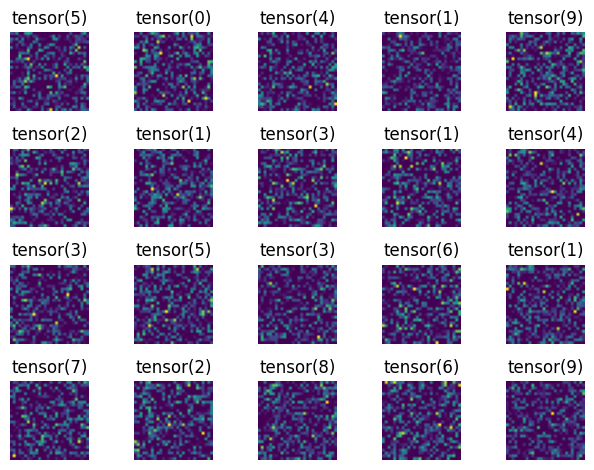

In [53]:
for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(output[i].detach().cpu().numpy())
    plt.title(train_label[i])
    plt.axis('off')
plt.tight_layout()

In [54]:
len(train_dataloader.dataset)

60000

In [55]:
train_losses = []
test_losses = []
train_steps = []
test_steps = [i * len(train_dataloader.dataset) for i in np.arange(n_epochs+1)] 

In [66]:
def train(epoch):
    vae_linear.train()
    for batch_id, (train_features, train_labels) in enumerate(train_dataloader):
        train_features, train_labels = train_features.to(device), train_labels.to(device)
        optimizer.zero_grad()
        output = vae_linear(train_features)
        mse_loss = F.mse_loss(output, train_features.reshape(train_features.shape[0], -1))
        mse_loss.backward()
        optimizer.step()

        if batch_id % log_interval == 0:
            train_losses.append(mse_loss.item())
            train_steps.append(epoch * len(train_dataloader.dataset) + batch_id * batch_size_train)            

            print(f'Epoch {epoch}, step: {batch_id * batch_size_train} / {len(train_dataloader.dataset)}, train loss: {train_losses[-1]}')

In [69]:
def test():
    vae_linear.eval()
    test_loss = 0

    with torch.no_grad():
        for test_features, test_labels in test_dataloader:
            test_features, test_labels = test_features.to(device), test_labels.to(device)
            output = vae_linear(test_features)
            test_loss += F.mse_loss(output, test_features.reshape(test_features.shape[0], -1)).item() 
    
        test_losses.append(test_loss / len(test_dataloader)) 

    print(f'Test set loss: {test_losses[-1]}') 

In [70]:
for epoch in np.arange(n_epochs):
    train(epoch)
    test() 

Epoch 0, step: 0 / 60000, train loss: 0.9193728566169739
Epoch 0, step: 6400 / 60000, train loss: 0.9768322110176086
Epoch 0, step: 12800 / 60000, train loss: 0.8176338076591492
Epoch 0, step: 19200 / 60000, train loss: 1.0470560789108276
Epoch 0, step: 25600 / 60000, train loss: 0.8923380374908447
Epoch 0, step: 32000 / 60000, train loss: 0.8804388046264648
Epoch 0, step: 38400 / 60000, train loss: 0.812821090221405
Epoch 0, step: 44800 / 60000, train loss: 0.7812536954879761
Epoch 0, step: 51200 / 60000, train loss: 0.880577564239502
Epoch 0, step: 57600 / 60000, train loss: 0.7914270758628845
Epoch 1, step: 0 / 60000, train loss: 0.7768046855926514
Epoch 1, step: 6400 / 60000, train loss: 0.8312197327613831
Epoch 1, step: 12800 / 60000, train loss: 0.7400350570678711
Epoch 1, step: 19200 / 60000, train loss: 0.8648548126220703
Epoch 1, step: 25600 / 60000, train loss: 0.8051212430000305
Epoch 1, step: 32000 / 60000, train loss: 0.8007720708847046
Epoch 1, step: 38400 / 60000, train 

Text(0, 0.5, 'loss')

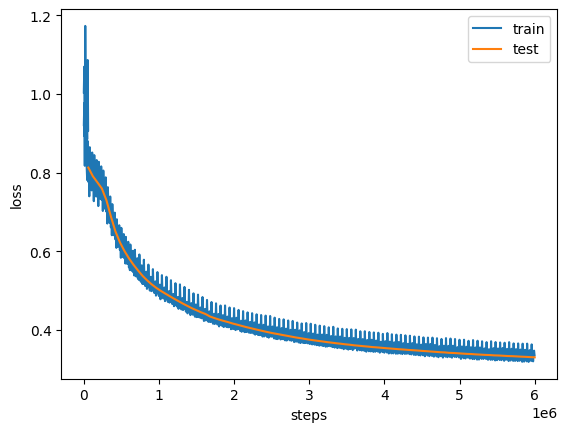

In [75]:
plt.plot(train_steps, train_losses[1:])
plt.plot(test_steps[1:], test_losses)
plt.legend(['train', 'test'])
plt.xlabel('steps')
plt.ylabel('loss') 

In [76]:
# after training, the VAE should be able to encode images
output = vae_linear(train_feature.to(device)) 
output = output.reshape(output.shape[0], 28, 28) 
output.shape 

torch.Size([64, 28, 28])

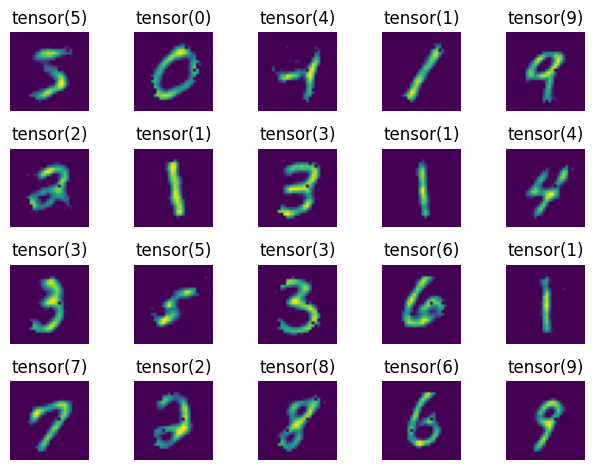

In [77]:
for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(output[i].detach().cpu().numpy())
    plt.title(train_label[i])
    plt.axis('off')
plt.tight_layout()

In [80]:
z = torch.randn(30, latent_dim)
with torch.no_grad():
    new_output = vae_linear.decode(z.to(device)) 

new_output = new_output.reshape(new_output.shape[0], 28, 28)

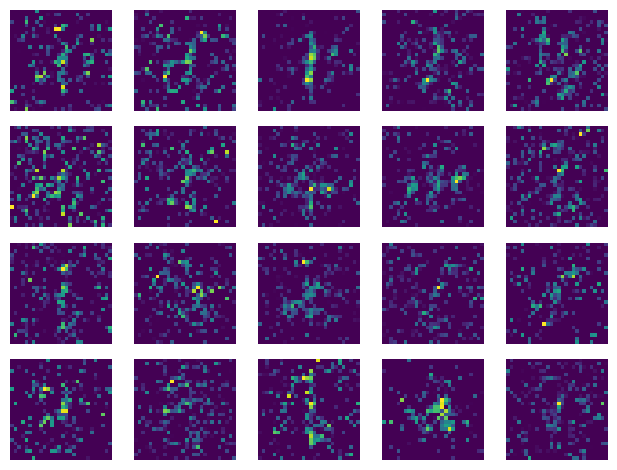

In [81]:
for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(new_output[i].detach().cpu().numpy())
    plt.axis('off')
plt.tight_layout()